In [14]:
## Importamos las librerias necesarias
import pandas as pd
import numpy as np
import unicodedata
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Ejercicio 1. Limpieza e imputación de un conjunto de datos mixto

In [ ]:
df = pd.DataFrame({
    'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
    'Edad': [25, np.nan, 35, 29, -5, 25, None],
    'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
    'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
    'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
})

In [ ]:
## Mostramos el dataframe para tener mas contexto de los datos
print(df.dtypes)
print("\n")
display(df)

Nombre           object
Edad            float64
Ciudad           object
Ingreso         float64
FechaIngreso     object
dtype: object




,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,Bogotá,3500.0,2023-01-01
1,Luis,NaN,Medellín,4800.0,2023-01-05
2,Pedro,35.0,None,NaN,None
3,None,29.0,Medellín,5200.0,2023-01-10
4,Marta,-5.0,Cali,5100.0,2023-01-12
5,Luis,25.0,Bogotá,NaN,None
6,Sofía,NaN,Cali,4700.0,2023-01-15


In [ ]:
##Visualizamos valores faltantes, nulls
df.isnull().sum()

,0
Nombre,1
Edad,2
Ciudad,1
Ingreso,2
FechaIngreso,2


In [ ]:
# Imputamos los valores nulos en la columna Nombre con 'Desconocido'
df['Nombre'] = df['Nombre'].fillna('Desconocido')

LO mas apropiado en este tipo de columnas es imputar con la palabra desconocido para mantener la integridad de los datos, esto para variables categoricas y evitar poner un nimbre que me pueda generar errores, no vamos a eliminar las filas, porque no queremos perder informacion importante


In [ ]:
# Corregimos la Edad: Limpieza e Imputación
# Convertimos a numérico primero para asegurar que podemos operar matemáticamente
df['Edad'] = pd.to_numeric(df['Edad'], errors='coerce')

# Reemplazamos valores negativos por NaN (limpieza)
df.loc[df['Edad'] < 0, 'Edad'] = np.nan

# Imputamos los valores nulos con la mediana
mediana_edad = df['Edad'].median()
df['Edad'] = df['Edad'].fillna(mediana_edad)

# Ahora que no hay nulos ni inconsistencias, podemos asegurar el tipo entero (opcional)
df['Edad'] = df['Edad'].astype(int)

La edad decidimos imputarla con la mediana, porque es robuzta frente a valores atipicos, y no se ve afectados por estos, ademas nos ayuda a preservar la distribucion, la forma

In [ ]:
def normalize_text(text):
    if isinstance(text, str):
        # Quitamos acentos
        text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
        # Pasamos a mayúsculas
        return text.upper()
    return text

# Aplicamos la normalización a la columna Ciudad
df['Ciudad'] = df['Ciudad'].apply(normalize_text)

In [ ]:
# Imputamos los valores nulos en la columna Ciudad con 'DESCONOCIDA'
df['Ciudad'] = df['Ciudad'].fillna('DESCONOCIDA')

Igual que con los nombres, la columna ciudad la imputamos de igual manera, por laas mismas razones, ademas quitamos acentos, para evitar que dos nombres iguales se tomen como diferentes


In [ ]:
## Imputamos la columna Ingresos
mediana_ingreso = df['Ingreso'].median()
df['Ingreso'] = df['Ingreso'].fillna(mediana_ingreso)

igual que con la edad, imputamos ingresos, con la mediana, por las mismas razones


In [ ]:
# Aseguramos que FechaIngreso sea datetime
df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'], errors='coerce')

# Imputamos los valores nulos (NaT) con '1900-01-01'
df['FechaIngreso'] = df['FechaIngreso'].fillna(pd.to_datetime('1900-01-01'))

# Quitamos la hora, dejando solo la fecha
df['FechaIngreso'] = df['FechaIngreso'].dt.date

imputamos con una fecha que sea poco probable que represente una fecha de interes, es como un marcador de datos faltantes


In [ ]:
# Mostramos los tipos resultantes y el DataFrame
print(df.dtypes)
print("\n")
display(df)

Nombre           object
Edad              int64
Ciudad           object
Ingreso         float64
FechaIngreso     object
dtype: object




,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25,BOGOTA,3500.0,2023-01-01
1,Luis,27,MEDELLIN,4800.0,2023-01-05
2,Pedro,35,DESCONOCIDA,4800.0,1900-01-01
3,Desconocido,29,MEDELLIN,5200.0,2023-01-10
4,Marta,27,CALI,5100.0,2023-01-12
5,Luis,25,BOGOTA,4800.0,1900-01-01
6,Sofía,27,CALI,4700.0,2023-01-15


# Ejercicio 2. Limpieza de duplicados

In [ ]:
df = pd.DataFrame({
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                    '2023-01-15', '2023-01-15', '2023-01-16']
})

In [ ]:
## Mostramos el dataframe para tener mas contexto de los datos
print(df.dtypes)
print("\n")
display(df)

ID                int64
Nombre           object
Edad              int64
Ciudad           object
FechaRegistro    object
dtype: object




,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


In [ ]:
# 1. ¿Cuál es el total de registros originales?
total_registros_originales = len(df)
print(f"Total de registros originales: {total_registros_originales}")

Total de registros originales: 7


In [ ]:
# 2. ¿Cuáles y cuántos son los duplicados exactos?
duplicados_exactos = df[df.duplicated(keep=False)]
num_duplicados_exactos = len(duplicados_exactos)

print(f"Cantidad de duplicados exactos (incluyendo la primera aparición): {num_duplicados_exactos}")
print("\n")

print("Registros duplicados exactos:")
display(duplicados_exactos.sort_values(by=list(df.columns)))

Cantidad de duplicados exactos (incluyendo la primera aparición): 4


Registros duplicados exactos:


,ID,Nombre,Edad,Ciudad,FechaRegistro
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15


visualizamos cuales son los duplicados, y para que se cuente comom duplicado, tiene que ser exactamente igual cada uno de los datos

In [ ]:
# 3. ¿Cuáles y cuántos son los duplicados por varias columnas (ej. 'ID', 'Nombre')?
# Consideraremos duplicados por 'ID' y 'Nombre'.
columnas_para_duplicados = ['ID', 'Nombre']
duplicados_por_columnas = df[df.duplicated(subset=columnas_para_duplicados, keep=False)]
num_duplicados_por_columnas = len(duplicados_por_columnas)

print(f"Cantidad de duplicados por '{', '.join(columnas_para_duplicados)}' (incluyendo la primera aparición): {num_duplicados_por_columnas}")
print("\n")

print(f"Registros duplicados por '{', '.join(columnas_para_duplicados)}':")
display(duplicados_por_columnas.sort_values(by=columnas_para_duplicados))

Cantidad de duplicados por 'ID, Nombre' (incluyendo la primera aparición): 5


Registros duplicados por 'ID, Nombre':


,ID,Nombre,Edad,Ciudad,FechaRegistro
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


In [ ]:
# 4. ¿Cuántos registros debes eliminar (si mantenemos la primera ocurrencia de cada duplicado exacto)?
registros_a_eliminar = df.duplicated(keep='first').sum()

print(f"Cantidad de registros a eliminar para dejar solo una ocurrencia de cada duplicado exacto: {registros_a_eliminar}")

Cantidad de registros a eliminar para dejar solo una ocurrencia de cada duplicado exacto: 2


In [ ]:
# 5. ¿Cuántos registros quedan después de la limpieza (eliminando duplicados exactos)?
df_limpio = df.drop_duplicates(keep='first')
registros_despues_limpieza = len(df_limpio)

print(f"Cantidad de registros restantes después de eliminar duplicados exactos: {registros_despues_limpieza}")
print("\n")

print("DataFrame después de eliminar duplicados exactos:")
display(df_limpio)

Cantidad de registros restantes después de eliminar duplicados exactos: 5


DataFrame después de eliminar duplicados exactos:


,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
4,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


# Ejercicio 3. Corrección de errores tipográficos o de codificación

In [ ]:
df = pd.DataFrame({
    'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
})

In [ ]:
def normalize_text(text):
    if isinstance(text, str):
        ## Quitamos acentos
        text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
        ## Pasamos a mayúsculas
        return text.upper()
    return text

## Aplicamos la normalización a la columna Ciudad
df['Ciudad'] = df['Ciudad'].apply(normalize_text)

Normalizamos quitando el acento y poniendo todo en mayuscula, como hicimos en el ejercicio numero 1


In [ ]:
## Mostramos el DataFrame con la columna Ciudad normalizada
display(df)

,Ciudad
0,BOGOTA
1,BOGOTA
2,BOGOTA
3,BOGOTA
4,BOGATA
5,BOGOTA
6,BOGOTA
7,CALI
8,CALI
9,MEDELLIN


# Ejercicio 4. Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)

### **Escenario 1**
Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).

**R/** MCAR, es completamente aleatorio como nos dice ahi, sin depender de absolutamente nada.

<br>

### **Escenario 2**
Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.

**R/** MAR, porque el valor faltante depende de una variable observada, en este caso, la de promedio.

<br>

### **Escenario 3**
Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.

**R/** MAR, porque el valor faltante depende de una variable observada, en este caso, la de promedio.

<br>

### **Escenario 4**
Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.

**R/** MAR, la falta de informacion en a variable promedio academico esta vinculada a una variable bservada, que es el genero.

<br>

### **Escenario 5**
Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.

**R/** MNAR, pues el que esos datos falten no es de manera aleatoria y depende unicamente de que ese dato falta, por decision de el estudiante.

#Ejercicio 5. Imputación con KNN y regresión


In [ ]:
np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Introducción de valores faltantes con distintos patrones
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

In [ ]:
# Exploración inicial
print("Conteo de valores faltantes por columna:")
print(df.isnull().sum())

print("\nProporción de valores faltantes (%):")
print(round((df.isnull().sum() / len(df)) * 100, 2))

print("\n")
display(df)

Conteo de valores faltantes por columna:
Edad                  0
Promedio              4
Horas_estudio         4
Ingreso_familiar      3
Semestres_cursados    0
dtype: int64

Proporción de valores faltantes (%):
Edad                   0.00
Promedio              13.33
Horas_estudio         13.33
Ingreso_familiar      10.00
Semestres_cursados     0.00
dtype: float64




,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56,2.70,35.0,2909818.0,7
1,46,2.27,NaN,3031785.0,7
2,32,NaN,30.0,5283302.0,9
3,25,3.15,14.0,NaN,3
4,38,4.95,7.0,3525928.0,7
5,56,NaN,13.0,4653339.0,1
6,36,4.58,22.0,NaN,4
7,40,4.04,NaN,1879111.0,4
8,28,NaN,20.0,1796107.0,5
9,28,2.04,15.0,4321441.0,7


### Análisis inicial

**1. ¿Qué variables tienen mayor proporción de datos faltantes?**
* **Promedio:** Faltan 4 datos (en los índices 2, 5, 8, 15) -> 13.3%
* **Horas_estudio:** Faltan 4 datos (en los índices 1, 7, 10, 18) -> 13.3%
* **Ingreso_familiar:** Faltan 3 datos (en los índices 3, 6, 14) -> 10%

Las variables con mayor proporción de datos faltantes son **Promedio** y **Horas_estudio**. Las variables `Edad` y `Semestres_cursados` están completamente llenas (0% de valores nulos).

**2. ¿Observas algún patrón estructurado o parecen aleatorios?**
Dado que los índices de los valores nulos fueron asignados manualmente y de forma independiente para cada columna (sin que una dependa de la otra), el patrón es MCAR.

In [ ]:
# Imputación con KNN
df_knn = df.copy()
imputer_knn = KNNImputer(n_neighbors=3)

# Ajustamos y transformamos los datos. El resultado es un array de numpy, por lo que lo volvemos a convertir a DataFrame
df_knn_imputed = pd.DataFrame(imputer_knn.fit_transform(df_knn), columns=df.columns)

# Se ajustan los tipos de datos a su naturaleza original
df_knn_imputed['Horas_estudio'] = df_knn_imputed['Horas_estudio'].round()
df_knn_imputed['Ingreso_familiar'] = df_knn_imputed['Ingreso_familiar'].round()
df_knn_imputed['Promedio'] = df_knn_imputed['Promedio'].round(2)

print("Valores faltantes después de imputación KNN:")
print(df_knn_imputed.isnull().sum())

# Mostrar las primeras filas para observar las imputaciones
print("\n")
display(df_knn_imputed.head(10))

Valores faltantes después de imputación KNN:
Edad                  0
Promedio              0
Horas_estudio         0
Ingreso_familiar      0
Semestres_cursados    0
dtype: int64




,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56.0,2.70,35.0,2909818.0,7.0
1,46.0,2.27,21.0,3031785.0,7.0
2,32.0,3.47,30.0,5283302.0,9.0
3,25.0,3.15,14.0,2955269.0,3.0
4,38.0,4.95,7.0,3525928.0,7.0
5,56.0,3.47,13.0,4653339.0,1.0
6,36.0,4.58,22.0,3609593.0,4.0
7,40.0,4.04,21.0,1879111.0,4.0
8,28.0,3.47,20.0,1796107.0,5.0
9,28.0,2.04,15.0,4321441.0,7.0


In [ ]:
# Imputación por Regresión Lineal
df_reg = df.copy()

""" Identificamos las variables a imputar y las predictoras. Se utilizan las
variables que están 100% completas ('Edad' y 'Semestres_cursados') como predictoras
# para evitar errores de NaN en el conjunto de entrenamiento (X).
"""
cols_con_na = ['Promedio', 'Horas_estudio', 'Ingreso_familiar']
cols_predictoras = ['Edad', 'Semestres_cursados']

for col in cols_con_na:
    mask_missing = df_reg[col].isnull()

    X_train = df_reg.loc[~mask_missing, cols_predictoras]
    y_train = df_reg.loc[~mask_missing, col]

    X_missing = df_reg.loc[mask_missing, cols_predictoras]

    reg = LinearRegression()
    reg.fit(X_train, y_train)

    # Predecir e imputar los valores en el DataFrame
    df_reg.loc[mask_missing, col] = reg.predict(X_missing)

# Asegurar que las predicciones respeten los rangos lógicos de la naturaleza del dato
df_reg['Promedio'] = np.clip(df_reg['Promedio'].round(2), 0.0, 5.0)
df_reg['Horas_estudio'] = np.clip(df_reg['Horas_estudio'].round(), 0, None)
df_reg['Ingreso_familiar'] = np.clip(df_reg['Ingreso_familiar'].round(), 0, None)

print("Valores faltantes después de imputación por Regresión:")
print(df_reg.isnull().sum())

# Mostrar las primeras filas
print("\n")
display(df_reg.head(10))

Valores faltantes después de imputación por Regresión:
Edad                  0
Promedio              0
Horas_estudio         0
Ingreso_familiar      0
Semestres_cursados    0
dtype: int64




,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56,2.70,35.0,2909818.0,7
1,46,2.27,19.0,3031785.0,7
2,32,3.34,30.0,5283302.0,9
3,25,3.15,14.0,4296336.0,3
4,38,4.95,7.0,3525928.0,7
5,56,3.47,13.0,4653339.0,1
6,36,4.58,22.0,4239592.0,4
7,40,4.04,19.0,1879111.0,4
8,28,3.28,20.0,1796107.0,5
9,28,2.04,15.0,4321441.0,7


### Análisis de la preservación de la naturaleza de los datos

**1. KNN:** Preserva muy bien la naturaleza y distribución de los datos originales. Al basarse en la similitud espacial (vecinos), los valores imputados siempre caen dentro del rango realista de los datos similares. Pero al promediar los K vecinos, las variables que son estrictamente enteras (como `Horas_estudio` o `Ingreso_familiar`) pueden arrojar números decimales. Por eso, es prácticamente necesario aplicar un redondeo al resultado final para preservar su naturaleza.

**2. Regresión Lineal:** Preserva la coherencia estadística y la relación entre las variables (por ejemplo, si a mayor edad y a mayor cantidad de semestres cursados resulta haber un patrón de mayores ingresos, el modelo lo captura y lo refleja en la imputación). Sin embargo, la regresión reduce la varianza natural de los datos, ya que los valores imputados caen exactamente sobre una línea de tendencia matemática, eliminando el ruido o variabilidad natural que sí existe en la vida real. Además, un modelo lineal no conoce los límites físicos o lógicos de los datos. Por ello, es obligatorio aplicar funciones de tope para garantizar que la imputación no rompa la lógica del negocio.

#Ejercicio 6. Imputación con LOCF y NOCB

In [15]:
np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
    'Ventas': np.round(np.random.uniform(100, 500, n), 2),
    'Inventario': np.random.randint(10, 100, n),
    'Clientes': np.random.randint(1, 50, n)
})

# Guardar una copia del DataFrame completo antes de introducir valores faltantes
df_original_complete = df.copy()

# Introducción de valores faltantes
df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
df.loc[[7, 8, 20], 'Inventario'] = np.nan
df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
df = df.sort_values('Fecha').reset_index(drop=True)

In [5]:
## Mostramos el dataframe para tener mas contexto de los datos
display(df)

,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.0,29.0
1,2023-01-02,480.29,16.0,NaN
2,2023-01-03,392.80,30.0,NaN
3,2023-01-04,NaN,82.0,44.0
4,2023-01-05,NaN,48.0,34.0
5,2023-01-06,NaN,27.0,10.0
6,2023-01-07,123.23,13.0,36.0
7,2023-01-08,446.47,NaN,14.0
8,2023-01-09,340.45,NaN,31.0
9,2023-01-10,383.23,23.0,48.0


### Análisis inicial

**1. ¿Qué variables presentan datos faltantes consecutivos?**
* **Ventas:** Faltan en los índices [3, 4, 5] y [12, 13].
* **Inventario:** Faltan en [7, 8] y el [20].
* **Clientes:** Faltan en [1, 2] y [18, 19].

**2. ¿Por qué este tipo de patrón es relevante en series temporales?**
Dado que se trabaja con series de tiempo, si faltan varios días seguidos, rellenar esto con el promedio global sería un error, porque no se tendría en cuenta la tendencia de esos días. Al faltar un bloque de tiempo, se necesita mirar los datos vecinos (antes o después de la falla) para mantener la coherencia.

**3. ¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?**
El orden de las fechas es crítico. LOCF y NOCB asumen que los eventos cercanos en el tiempo tienen valores similares. Si el DataFrame no está ordenado por `Fecha`, estos métodos imputarían valores provenientes de meses o años diferentes, dañando por completo la secuencia temporal.

In [16]:
# Imputación con LOCF y NOCB
df_locf = df.copy()
df_nocb = df.copy()

# Aplicar LOCF
df_locf['Ventas'] = df_locf['Ventas'].ffill()
df_locf['Inventario'] = df_locf['Inventario'].ffill()
df_locf['Clientes'] = df_locf['Clientes'].ffill()

# Aplicar NOCB
df_nocb['Ventas'] = df_nocb['Ventas'].bfill()
df_nocb['Inventario'] = df_nocb['Inventario'].bfill()
df_nocb['Clientes'] = df_nocb['Clientes'].bfill()

print("Faltantes después de LOCF:\n", df_locf.isnull().sum())
print("\nFaltantes después de NOCB:\n", df_nocb.isnull().sum())

Faltantes después de LOCF:
 Fecha         0
Ventas        0
Inventario    0
Clientes      0
dtype: int64

Faltantes después de NOCB:
 Fecha         0
Ventas        0
Inventario    0
Clientes      0
dtype: int64


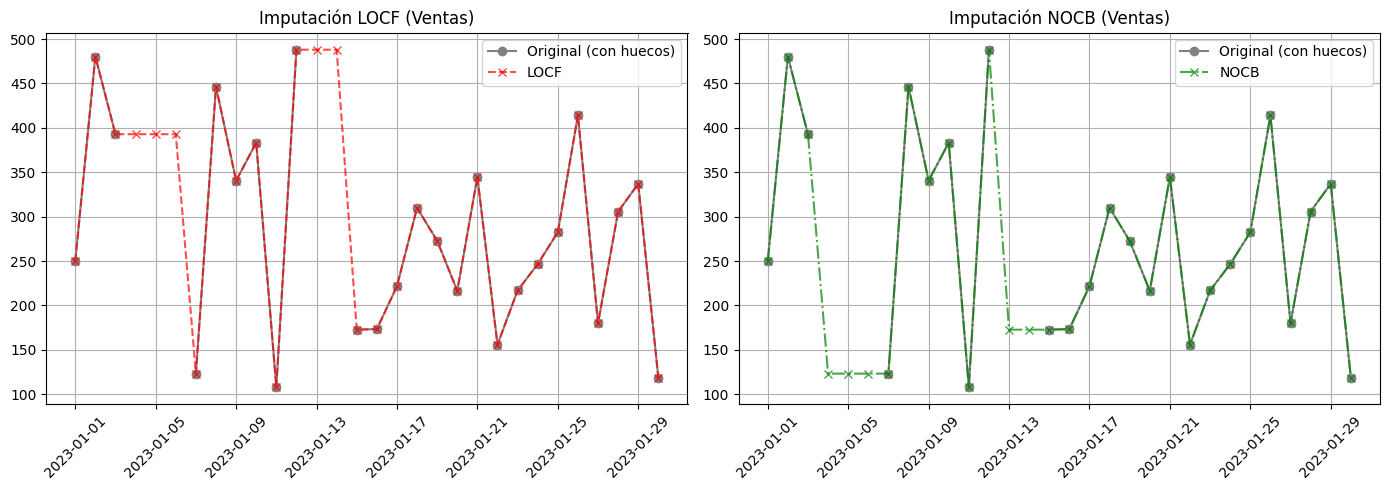

In [17]:
plt.figure(figsize=(14, 5))

# LOCF
plt.subplot(1, 2, 1)
plt.plot(df['Fecha'], df['Ventas'], color='gray', label='Original (con huecos)', marker='o')
plt.plot(df_locf['Fecha'], df_locf['Ventas'], color='red', linestyle='--', label='LOCF', marker='x', alpha=0.7)
plt.title('Imputación LOCF (Ventas)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# NOCB
plt.subplot(1, 2, 2)
plt.plot(df['Fecha'], df['Ventas'], color='gray', label='Original (con huecos)', marker='o')
plt.plot(df_nocb['Fecha'], df_nocb['Ventas'], color='green', linestyle='-.', label='NOCB', marker='x', alpha=0.7)
plt.title('Imputación NOCB (Ventas)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Comparación de MAE (Error Absoluto Medio) para LOCF y NOCB en la columna 'Ventas'

MAE para LOCF en Ventas: 174.43
MAE para NOCB en Ventas: 113.41


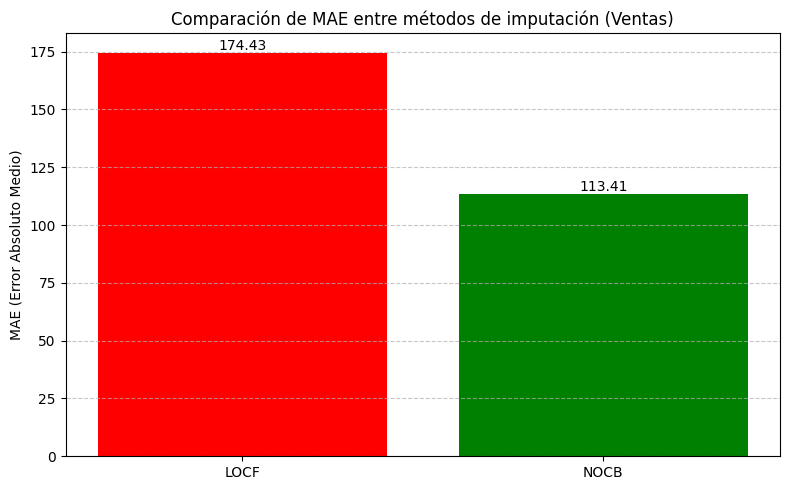

In [18]:
# Guardar una copia de la columna 'Ventas' original completa para el cálculo de errores
original_ventas = df_original_complete['Ventas'].copy()

# Identificar los índices donde 'Ventas' era NaN en el DataFrame *modificado* (df)
indices_missing_ventas = df['Ventas'].isnull()

# Calcular errores absolutos solo en las posiciones donde había NaN
errores_locf_ventas = np.abs(original_ventas[indices_missing_ventas] - df_locf['Ventas'][indices_missing_ventas])
errores_nocb_ventas = np.abs(original_ventas[indices_missing_ventas] - df_nocb['Ventas'][indices_missing_ventas])

# Calcular el MAE
mae_locf = errores_locf_ventas.mean()
mae_nocb = errores_nocb_ventas.mean()

# Mostrar los resultados
print(f"MAE para LOCF en Ventas: {mae_locf:.2f}")
print(f"MAE para NOCB en Ventas: {mae_nocb:.2f}")

# Preparar datos para el gráfico
metodos = ['LOCF', 'NOCB']
mae_valores = [mae_locf, mae_nocb]

# Crear el gráfico de barras
plt.figure(figsize=(8, 5))
bars = plt.bar(metodos, mae_valores, color=['red', 'green'])
plt.title('Comparación de MAE entre métodos de imputación (Ventas)')
plt.ylabel('MAE (Error Absoluto Medio)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir los valores MAE en las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Visualización de imputación LOCF y NOCB para la columna 'Inventario'

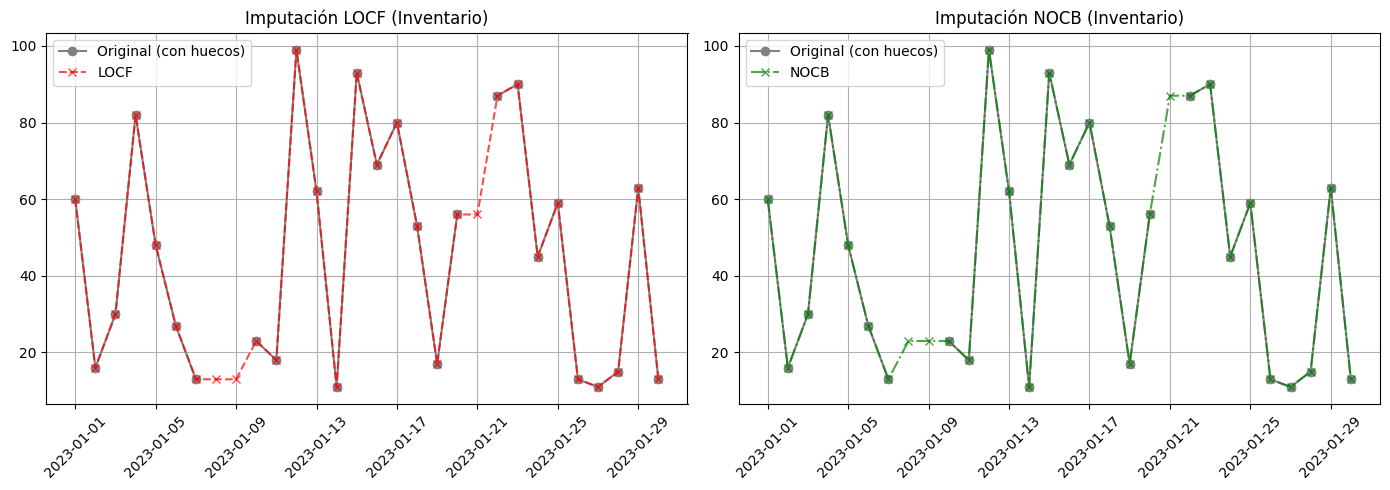

In [21]:
plt.figure(figsize=(14, 5))

# LOCF para Inventario
plt.subplot(1, 2, 1)
plt.plot(df['Fecha'], df['Inventario'], color='gray', label='Original (con huecos)', marker='o')
plt.plot(df_locf['Fecha'], df_locf['Inventario'], color='red', linestyle='--', label='LOCF', marker='x', alpha=0.7)
plt.title('Imputación LOCF (Inventario)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# NOCB para Inventario
plt.subplot(1, 2, 2)
plt.plot(df['Fecha'], df['Inventario'], color='gray', label='Original (con huecos)', marker='o')
plt.plot(df_nocb['Fecha'], df_nocb['Inventario'], color='green', linestyle='-.', label='NOCB', marker='x', alpha=0.7)
plt.title('Imputación NOCB (Inventario)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Comparación de MAE (Error Absoluto Medio) para LOCF y NOCB en la columna 'Inventario'

MAE para LOCF en Inventario: 51.00
MAE para NOCB en Inventario: 54.67


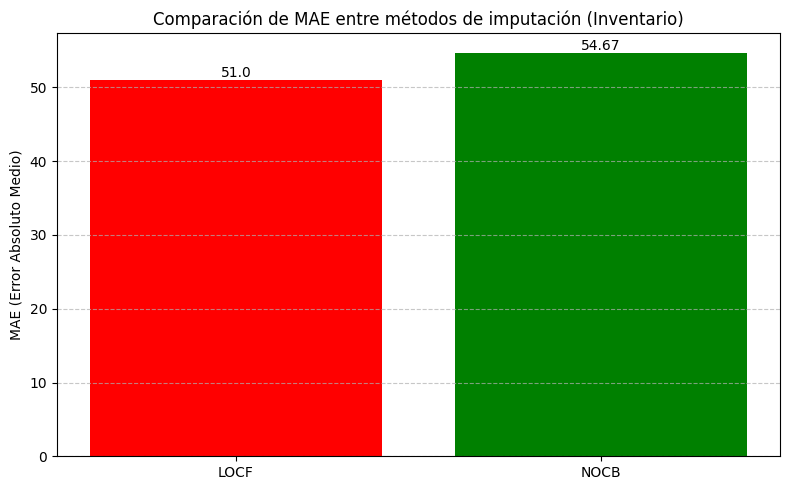

In [19]:
# Guardar una copia de la columna 'Inventario' original completa para el cálculo de errores
original_inventario = df_original_complete['Inventario'].copy()

# Identificar los índices donde 'Inventario' era NaN en el DataFrame *modificado* (df)
indices_missing_inventario = df['Inventario'].isnull()

# Calcular errores absolutos solo en las posiciones donde había NaN
errores_locf_inventario = np.abs(original_inventario[indices_missing_inventario] - df_locf['Inventario'][indices_missing_inventario])
errores_nocb_inventario = np.abs(original_inventario[indices_missing_inventario] - df_nocb['Inventario'][indices_missing_inventario])

# Calcular el MAE
mae_locf_inventario = errores_locf_inventario.mean()
mae_nocb_inventario = errores_nocb_inventario.mean()

# Mostrar los resultados
print(f"MAE para LOCF en Inventario: {mae_locf_inventario:.2f}")
print(f"MAE para NOCB en Inventario: {mae_nocb_inventario:.2f}")

# Preparar datos para el gráfico
metodos = ['LOCF', 'NOCB']
mae_valores = [mae_locf_inventario, mae_nocb_inventario]

# Crear el gráfico de barras
plt.figure(figsize=(8, 5))
bars = plt.bar(metodos, mae_valores, color=['red', 'green'])
plt.title('Comparación de MAE entre métodos de imputación (Inventario)')
plt.ylabel('MAE (Error Absoluto Medio)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir los valores MAE en las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Visualización de imputación LOCF y NOCB para la columna 'Clientes'

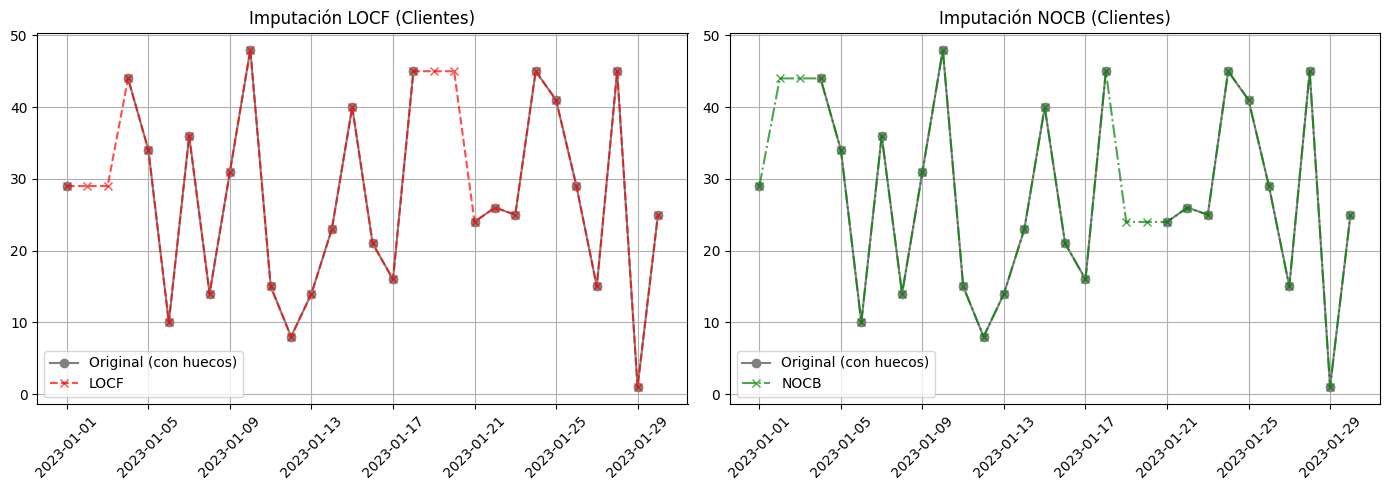

In [22]:
plt.figure(figsize=(14, 5))

# LOCF para Clientes
plt.subplot(1, 2, 1)
plt.plot(df['Fecha'], df['Clientes'], color='gray', label='Original (con huecos)', marker='o')
plt.plot(df_locf['Fecha'], df_locf['Clientes'], color='red', linestyle='--', label='LOCF', marker='x', alpha=0.7)
plt.title('Imputación LOCF (Clientes)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# NOCB para Clientes
plt.subplot(1, 2, 2)
plt.plot(df['Fecha'], df['Clientes'], color='gray', label='Original (con huecos)', marker='o')
plt.plot(df_nocb['Fecha'], df_nocb['Clientes'], color='green', linestyle='-.', label='NOCB', marker='x', alpha=0.7)
plt.title('Imputación NOCB (Clientes)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Comparación de MAE (Error Absoluto Medio) para LOCF y NOCB en la columna 'Clientes'

MAE para LOCF en Clientes: 10.75
MAE para NOCB en Clientes: 18.25


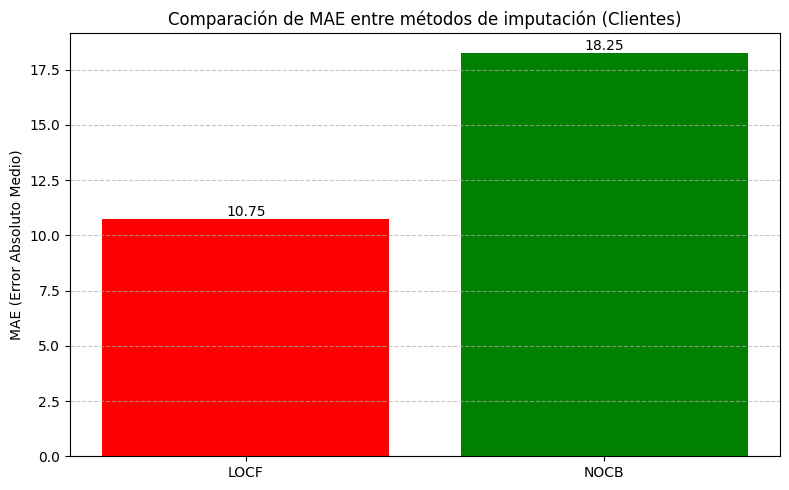

In [20]:
# Guardar una copia de la columna 'Clientes' original completa para el cálculo de errores
original_clientes = df_original_complete['Clientes'].copy()

# Identificar los índices donde 'Clientes' era NaN en el DataFrame *modificado* (df)
indices_missing_clientes = df['Clientes'].isnull()

# Calcular errores absolutos solo en las posiciones donde había NaN
errores_locf_clientes = np.abs(original_clientes[indices_missing_clientes] - df_locf['Clientes'][indices_missing_clientes])
errores_nocb_clientes = np.abs(original_clientes[indices_missing_clientes] - df_nocb['Clientes'][indices_missing_clientes])

# Calcular el MAE
mae_locf_clientes = errores_locf_clientes.mean()
mae_nocb_clientes = errores_nocb_clientes.mean()

# Mostrar los resultados
print(f"MAE para LOCF en Clientes: {mae_locf_clientes:.2f}")
print(f"MAE para NOCB en Clientes: {mae_nocb_clientes:.2f}")

# Preparar datos para el gráfico
metodos = ['LOCF', 'NOCB']
mae_valores = [mae_locf_clientes, mae_nocb_clientes]

# Crear el gráfico de barras
plt.figure(figsize=(8, 5))
bars = plt.bar(metodos, mae_valores, color=['red', 'green'])
plt.title('Comparación de MAE entre métodos de imputación (Clientes)')
plt.ylabel('MAE (Error Absoluto Medio)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir los valores MAE en las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

**¿Cuál método consideras más apropiado para este caso y por qué?**

Al analizar los valores de MAE para las tres columnas, encontramos lo siguiente:

*   Para **'Ventas'**: **NOCB** (113.41) tuvo un MAE menor que LOCF (174.43), sugiriendo que es más apropiado.
*   Para **'Inventario'**: **LOCF** (51.00) tuvo un MAE menor que NOCB (54.67), sugiriendo que es más apropiado.
*   Para **'Clientes'**: **LOCF** (10.75) tuvo un MAE menor que NOCB (18.25), sugiriendo que es más apropiado.

Esto resalta la importancia de evaluar diferentes métodos de imputación para cada variable, ya que sus patrones de datos y la forma en que se comportan los valores faltantes pueden influir en cuál método produce los resultados más precisos.

Sin embargo, es importante notar que, a pesar de haber elegido el mejor de los dos métodos simples (LOCF/NOCB) para cada columna, los valores de **MAE aún son considerablemente altos**. Esto indica que estas técnicas de imputación básicas podrían no estar capturando adecuadamente la tendencia real o la variabilidad de los datos.

Una alternativa que podría ofrecer mejores resultados, suavizando más los datos y reduciendo el error, es la **interpolación cuadrática**. Este método podría ajustarse mejor a patrones no lineales presentes en las series de tiempo, lo que potencialmente resultaría en un MAE menor y una imputación más precisa de los valores faltantes.